In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, classification_report

df = pd.read_csv('data/bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [39]:
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

In [40]:
print('total na values', df.isna().sum().sum())
print('total nulls', df.isnull().sum().sum())

total na values 0
total nulls 0


In [41]:
unknown_cols = ["job", "marital", "education", "default", "housing", "loan"]

unknown_summary = df[unknown_cols].apply(
    lambda col: pd.Series({
        "unknown_count": (col == "unknown").sum(),
        "unknown_pct": (col == "unknown").mean() * 100
    })
)

print(unknown_summary.T.sort_values("unknown_count", ascending=False))

           unknown_count  unknown_pct
default           8597.0    20.872584
education         1731.0     4.202680
housing            990.0     2.403613
loan               990.0     2.403613
job                330.0     0.801204
marital             80.0     0.194231


In [42]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [43]:
# it looks like we would need to remove duration because its a leaky variable and modify pdays to a flag

In [44]:
df.describe(include="object")


/var/folders/86/y8hz87g56y9dysdfgkpjgpm40000gn/T/ipykernel_28707/2168331446.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [45]:
# it looks like our y is imbalanced with no appearing more freq

In [46]:
cat_cols = ["job", "marital", "education", "default", "housing", "loan",
            "contact", "month", "day_of_week", "poutcome", "y"]

for col in cat_cols:
    summary = pd.DataFrame({
        "count": df[col].value_counts(dropna=False),
        "pct": (df[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    })
    print(f"\n=== {col} ===")
    print(summary)


=== job ===
               count    pct
job                        
admin.         10422  25.30
blue-collar     9254  22.47
technician      6743  16.37
services        3969   9.64
management      2924   7.10
retired         1720   4.18
entrepreneur    1456   3.54
self-employed   1421   3.45
housemaid       1060   2.57
unemployed      1014   2.46
student          875   2.12
unknown          330   0.80

=== marital ===
          count    pct
marital               
married   24928  60.52
single    11568  28.09
divorced   4612  11.20
unknown      80   0.19

=== education ===
                     count    pct
education                        
university.degree    12168  29.54
high.school           9515  23.10
basic.9y              6045  14.68
professional.course   5243  12.73
basic.4y              4176  10.14
basic.6y              2292   5.56
unknown               1731   4.20
illiterate              18   0.04

=== default ===
         count    pct
default              
no       32588  79.1

In [47]:
# may drop default because it looks like a weak signal

In [48]:
import numpy as np

df_mlp = df.copy()

# target
df_mlp["y"] = df_mlp["y"].map({"no": 0, "yes": 1})

# pdays features
df_mlp["previously_contacted"] = (df_mlp["pdays"] != 999).astype(int)
df_mlp["pdays_clean"] = df_mlp["pdays"].replace(999, np.nan)

# log transforms
df_mlp["campaign_log"] = np.log1p(df_mlp["campaign"])
df_mlp["previous_log"] = np.log1p(df_mlp["previous"])
df_mlp["pdays_log"] = np.log1p(df_mlp["pdays_clean"])

# recently contacted indicator
df_mlp["recently_contacted"] = ((df_mlp["pdays"] != 999) & (df_mlp["pdays"] <= 30)).astype(int)

# drop original columns that were replaced
df_mlp = df_mlp.drop(columns=[
    "default",
    "campaign",
    "previous",
    "pdays",
    "pdays_clean",
    "duration"
])

continuous_numeric_features = [
    "age",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed",
    "campaign_log", "previous_log", "pdays_log"
]

binary_features = [
    "previously_contacted",
    "recently_contacted"
]

categorical_features = [
    "job", "marital", "education", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome"
]

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# impute missing values with the median and
# standardize values w mean 0 and std dev 1
continuous_numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# impute missing values with most frequency category and
# one hot encode them
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", continuous_numeric_transformer, continuous_numeric_features),
    ("bin", binary_transformer, binary_features),
    ("cat", categorical_transformer, categorical_features)
])


In [50]:
from sklearn.model_selection import train_test_split

X = df_mlp.drop(columns=["y"])
y = df_mlp["y"]

# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# split the 30% temp into 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)



(28831, 20) (28831,)
(6178, 20) (6178,)
(6179, 20) (6179,)


In [51]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# sklearn MLP works best with dense arrays
X_train_processed = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_val_processed = X_val_processed.toarray() if hasattr(X_val_processed, "toarray") else X_val_processed
X_test_processed = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed



In [52]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)

# baseline MLP
baseline_mlp = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation="relu",
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)

baseline_mlp.fit(X_train_processed, y_train)

val_pred = baseline_mlp.predict(X_val_processed)
val_prob = baseline_mlp.predict_proba(X_val_processed)[:, 1]

print("Validation accuracy:", accuracy_score(y_val, val_pred))
print("Validation precision:", precision_score(y_val, val_pred))
print("Validation recall:", recall_score(y_val, val_pred))
print("Validation F1:", f1_score(y_val, val_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_prob))
print("Validation PR-AUC (Average Precision):", average_precision_score(y_val, val_prob))

Validation accuracy: 0.892198122369699
Validation precision: 0.5371287128712872
Validation recall: 0.3117816091954023
Validation F1: 0.39454545454545453
Validation ROC-AUC: 0.760136884768123
Validation PR-AUC (Average Precision): 0.3924880135539338


/Users/davidjuarez/PycharmProjects/AML-2/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


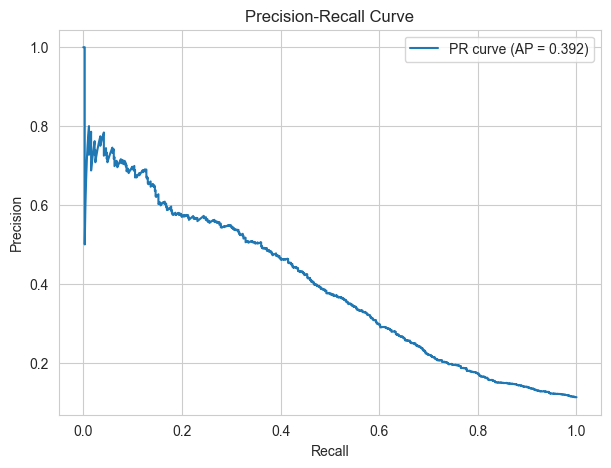

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_val, val_prob)
ap = average_precision_score(y_val, val_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

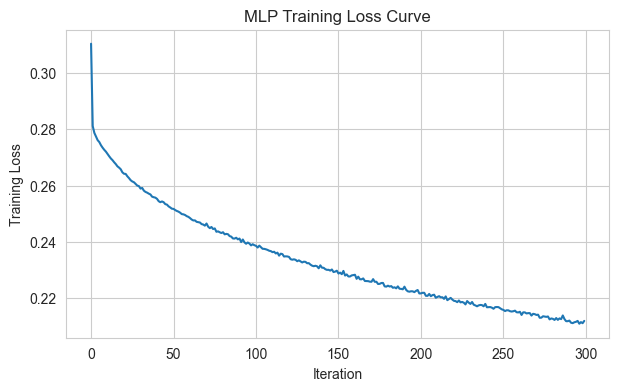

In [54]:
plt.figure(figsize=(7, 4))
plt.plot(baseline_mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("MLP Training Loss Curve")
plt.grid(True)
plt.show()

In [55]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(random_state=42)

param_distributions = {
    "hidden_layer_sizes": [(64,), (128, 64), (256, 128, 64)],
    "activation": ["relu", "tanh"],
    "learning_rate_init": [0.001, 0.01, 0.1],
    "max_iter": [200, 400, 600, 800]
}

random_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    return_train_score=True
)

random_search.fit(X_train_processed, y_train)

print("Best params:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END activation=relu, hidden_layer_sizes=(64,), learning_rate_init=0.01, max_iter=200; total time=   4.2s
[CV] END activation=relu, hidden_layer_sizes=(64,), learning_rate_init=0.01, max_iter=200; total time=   4.7s
[CV] END activation=relu, hidden_layer_sizes=(64,), learning_rate_init=0.01, max_iter=200; total time=   5.0s


/Users/davidjuarez/PycharmProjects/AML-2/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/davidjuarez/PycharmProjects/AML-2/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, hidden_layer_sizes=(64,), learning_rate_init=0.001, max_iter=200; total time=   6.8s
[CV] END activation=relu, hidden_layer_sizes=(64,), learning_rate_init=0.001, max_iter=200; total time=   7.0s


/Users/davidjuarez/PycharmProjects/AML-2/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, hidden_layer_sizes=(64,), learning_rate_init=0.001, max_iter=200; total time=   7.1s
[CV] END activation=relu, hidden_layer_sizes=(128, 64), learning_rate_init=0.01, max_iter=600; total time=   7.2s
[CV] END activation=relu, hidden_layer_sizes=(128, 64), learning_rate_init=0.01, max_iter=600; total time=   7.8s
[CV] END activation=relu, hidden_layer_sizes=(64,), learning_rate_init=0.1, max_iter=600; total time=   0.7s
[CV] END activation=relu, hidden_layer_sizes=(64,), learning_rate_init=0.1, max_iter=600; total time=   0.8s
[CV] END activation=relu, hidden_layer_sizes=(128, 64), learning_rate_init=0.01, max_iter=600; total time=   8.9s
[CV] END activation=relu, hidden_layer_sizes=(64,), learning_rate_init=0.1, max_iter=600; total time=   1.1s
[CV] END activation=relu, hidden_layer_sizes=(256, 128, 64), learning_rate_init=0.1, max_iter=600; total time=   6.0s
[CV] END activation=relu, hidden_layer_sizes=(256, 128, 64), learning_rate_init=0.1, max_iter=600; tot

/Users/davidjuarez/PycharmProjects/AML-2/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, hidden_layer_sizes=(128, 64), learning_rate_init=0.001, max_iter=200; total time=  16.5s
[CV] END activation=relu, hidden_layer_sizes=(64,), learning_rate_init=0.1, max_iter=400; total time=   0.5s
[CV] END activation=relu, hidden_layer_sizes=(64,), learning_rate_init=0.1, max_iter=400; total time=   0.7s
[CV] END activation=tanh, hidden_layer_sizes=(256, 128, 64), learning_rate_init=0.001, max_iter=600; total time=  33.1s
[CV] END activation=relu, hidden_layer_sizes=(128, 64), learning_rate_init=0.001, max_iter=200; total time=  16.6s
[CV] END activation=tanh, hidden_layer_sizes=(64,), learning_rate_init=0.1, max_iter=400; total time=   0.6s


/Users/davidjuarez/PycharmProjects/AML-2/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=tanh, hidden_layer_sizes=(128, 64), learning_rate_init=0.001, max_iter=600; total time=  26.3s
[CV] END activation=tanh, hidden_layer_sizes=(64,), learning_rate_init=0.1, max_iter=400; total time=   0.6s
[CV] END activation=tanh, hidden_layer_sizes=(64,), learning_rate_init=0.1, max_iter=400; total time=   1.0s
[CV] END activation=tanh, hidden_layer_sizes=(256, 128, 64), learning_rate_init=0.001, max_iter=600; total time=  34.6s
[CV] END activation=tanh, hidden_layer_sizes=(128, 64), learning_rate_init=0.01, max_iter=600; total time=   8.9s
[CV] END activation=relu, hidden_layer_sizes=(128, 64), learning_rate_init=0.1, max_iter=600; total time=   1.3s
[CV] END activation=relu, hidden_layer_sizes=(128, 64), learning_rate_init=0.1, max_iter=600; total time=   2.0s
[CV] END activation=relu, hidden_layer_sizes=(128, 64), learning_rate_init=0.1, max_iter=600; total time=   1.9s
[CV] END activation=tanh, hidden_layer_sizes=(128, 64), learning_rate_init=0.1, max_iter=200; 

/Users/davidjuarez/PycharmProjects/AML-2/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=tanh, hidden_layer_sizes=(64,), learning_rate_init=0.001, max_iter=800; total time=  25.7s


/Users/davidjuarez/PycharmProjects/AML-2/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=tanh, hidden_layer_sizes=(64,), learning_rate_init=0.001, max_iter=800; total time=  25.6s
[CV] END activation=tanh, hidden_layer_sizes=(64,), learning_rate_init=0.01, max_iter=600; total time=   8.1s
[CV] END activation=tanh, hidden_layer_sizes=(64,), learning_rate_init=0.01, max_iter=600; total time=   8.8s


/Users/davidjuarez/PycharmProjects/AML-2/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=tanh, hidden_layer_sizes=(64,), learning_rate_init=0.001, max_iter=800; total time=  25.0s
[CV] END activation=relu, hidden_layer_sizes=(256, 128, 64), learning_rate_init=0.01, max_iter=600; total time=  10.8s
[CV] END activation=relu, hidden_layer_sizes=(256, 128, 64), learning_rate_init=0.01, max_iter=600; total time=   9.1s
[CV] END activation=relu, hidden_layer_sizes=(256, 128, 64), learning_rate_init=0.01, max_iter=600; total time=  11.4s
Best params: {'max_iter': 600, 'learning_rate_init': 0.1, 'hidden_layer_sizes': (128, 64), 'activation': 'relu'}
Best CV F1: 0.39718568912548147


In [56]:
results_df = pd.DataFrame(random_search.cv_results_)

summary_table = results_df[[
    "param_hidden_layer_sizes",
    "param_activation",
    "param_learning_rate_init",
    "param_max_iter",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "rank_test_score"
]].copy()

summary_table = summary_table.sort_values("rank_test_score")

summary_table.head(10)

,param_hidden_layer_sizes,param_activation,param_learning_rate_init,param_max_iter,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score
15,"(128, 64)",relu,0.100,600,0.397186,0.064643,0.426513,0.043245,1
3,"(64,)",relu,0.001,200,0.358820,0.014863,0.588992,0.006195,2
29,"(64,)",tanh,0.100,600,0.349147,0.063685,0.384478,0.063363,3
23,"(64,)",tanh,0.100,200,0.349147,0.063685,0.384478,0.063363,3
13,"(64,)",tanh,0.100,400,0.349147,0.063685,0.384478,0.063363,3
10,"(64,)",tanh,0.100,800,0.349147,0.063685,0.384478,0.063363,3
4,"(256, 128, 64)",relu,0.010,200,0.346003,0.020885,0.914419,0.003192,7
28,"(256, 128, 64)",relu,0.010,600,0.346003,0.020885,0.914419,0.003192,7
11,"(256, 128, 64)",relu,0.010,800,0.346003,0.020885,0.914419,0.003192,7
1,"(256, 128, 64)",tanh,0.001,600,0.344073,0.008323,0.965989,0.004161,10


In [57]:
# best model from RandomizedSearchCV
best_mlp = random_search.best_estimator_

# predictions on validation set
val_pred_best = best_mlp.predict(X_val_processed)
val_prob_best = best_mlp.predict_proba(X_val_processed)[:, 1]

print("Best model:", best_mlp)
print("Validation accuracy:", accuracy_score(y_val, val_pred_best))
print("Validation precision:", precision_score(y_val, val_pred_best))
print("Validation recall:", recall_score(y_val, val_pred_best))
print("Validation F1:", f1_score(y_val, val_pred_best))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_prob_best))
print("Validation PR-AUC (Average Precision):", average_precision_score(y_val, val_prob_best))

Best model: MLPClassifier(hidden_layer_sizes=(128, 64), learning_rate_init=0.1,
              max_iter=600, random_state=42)
Validation accuracy: 0.89640660407899
Validation precision: 0.64
Validation recall: 0.1839080459770115
Validation F1: 0.2857142857142857
Validation ROC-AUC: 0.7895667954056536
Validation PR-AUC (Average Precision): 0.3931391410743364


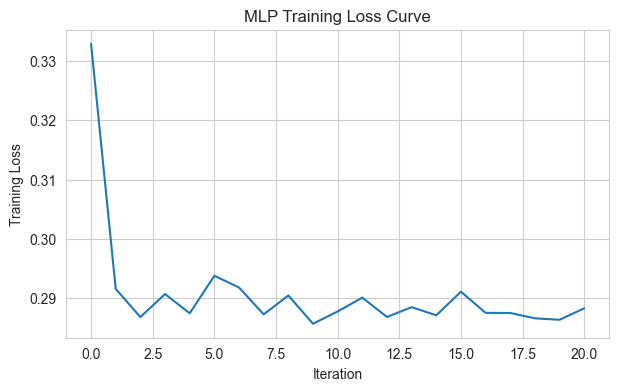

In [58]:
plt.figure(figsize=(7, 4))
plt.plot(best_mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("MLP Training Loss Curve")
plt.grid(True)
plt.show()

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# put cv results into a dataframe
results_df = pd.DataFrame(random_search.cv_results_)

# keep only architecture and validation score
arch_perf = results_df.groupby("param_hidden_layer_sizes", as_index=False)["mean_test_score"].agg(["mean", "std", "max"])
arch_perf = arch_perf.reset_index()

print(arch_perf)

   index param_hidden_layer_sizes      mean       std       max
0      0                    (64,)  0.324374  0.042806  0.358820
1      1                (128, 64)  0.294347  0.092740  0.397186
2      2           (256, 128, 64)  0.228189  0.134441  0.346003


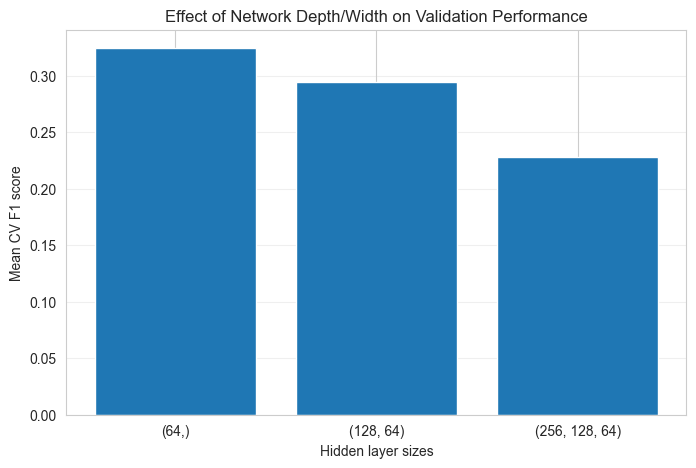

In [60]:
plt.figure(figsize=(8,5))
plt.bar(
    arch_perf["param_hidden_layer_sizes"].astype(str),
    arch_perf["mean"],
    capsize=5
)
plt.xlabel("Hidden layer sizes")
plt.ylabel("Mean CV F1 score")
plt.title("Effect of Network Depth/Width on Validation Performance")
plt.grid(axis="y", alpha=0.3)
plt.show()

# GBDT

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, precision_score, recall_score,
    classification_report, log_loss
)

from xgboost import XGBClassifier, plot_importance

In [62]:
df = pd.read_csv('data/bank-additional-full.csv', sep=';')
df_gbt = df.copy()
df_gbt["y"] = df_gbt["y"].map({"no": 0, "yes": 1})

In [63]:
# pdays: 999 means not previously contacted
df_gbt["previously_contacted"] = (df_gbt["pdays"] != 999).astype(int)

# replace 999 with a more meaningful value after creating the indicator
df_gbt["pdays_clean"] = df_gbt["pdays"].replace(999, -1)

# drop the original pdays once pdays_clean is created
df_gbt = df_gbt.drop(columns=["pdays"])

# drop default because of noise
df_gbt = df_gbt.drop(columns=["default"])

df_gbt = df_gbt.drop(columns=["duration"])

In [64]:
X = df_gbt.drop(columns=["y"])
y = df_gbt["y"]

In [65]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (28831, 19)
Val shape: (6178, 19)
Test shape: (6179, 19)


In [66]:
X_train_enc = pd.get_dummies(X_train, drop_first=False)
X_val_enc = pd.get_dummies(X_val, drop_first=False)
X_test_enc = pd.get_dummies(X_test, drop_first=False)

# align columns so validation/test match training exactly
X_val_enc = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print("Encoded training shape:", X_train_enc.shape)

Encoded training shape: (28831, 60)


In [67]:
xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=500,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    min_child_weight=1,
    random_state=42,
    early_stopping_rounds=30
)

xgb_baseline.fit(
    X_train_enc, y_train,
    eval_set=[(X_train_enc, y_train), (X_val_enc, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [68]:
val_pred_baseline = xgb_baseline.predict(X_val_enc)
val_prob_baseline = xgb_baseline.predict_proba(X_val_enc)[:, 1]

print("Validation accuracy:", accuracy_score(y_val, val_pred_baseline))
print("Validation precision:", precision_score(y_val, val_pred_baseline))
print("Validation recall:", recall_score(y_val, val_pred_baseline))
print("Validation F1:", f1_score(y_val, val_pred_baseline))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_prob_baseline))
print("Validation PR-AUC (Average Precision):", average_precision_score(y_val, val_prob_baseline))

Validation accuracy: 0.9027193266429265
Validation precision: 0.673992673992674
Validation recall: 0.26436781609195403
Validation F1: 0.3797729618163055
Validation ROC-AUC: 0.8128476634083541
Validation PR-AUC (Average Precision): 0.49166484624735096


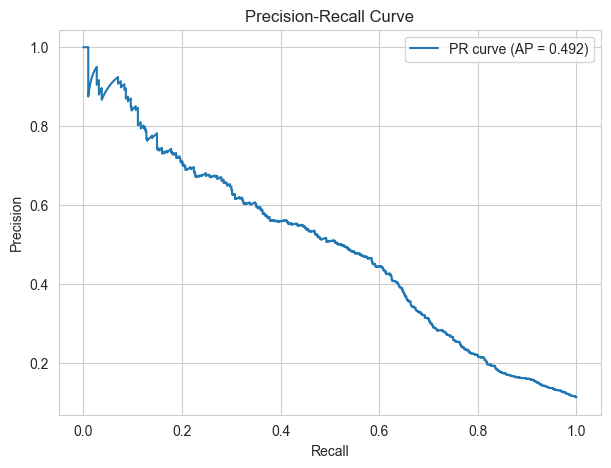

In [69]:
val_pred_baseline = xgb_baseline.predict(X_val_enc)
val_prob_baseline = xgb_baseline.predict_proba(X_val_enc)[:, 1]

precision, recall, _ = precision_recall_curve(y_val, val_prob_baseline)
ap = average_precision_score(y_val, val_prob_baseline)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

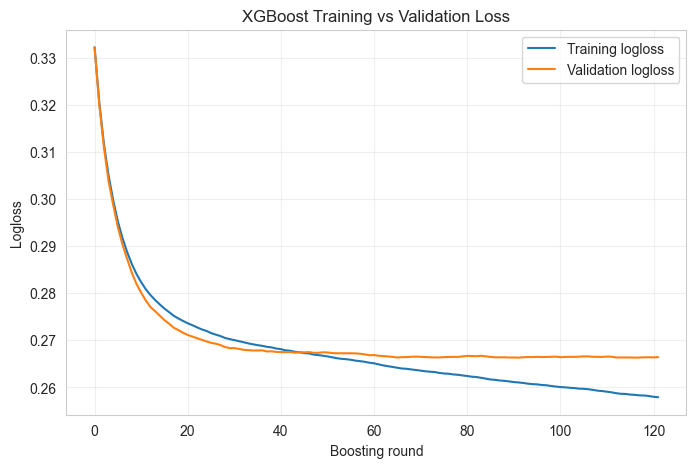

In [36]:
results = xgb_baseline.evals_result()

train_logloss = results["validation_0"]["logloss"]
val_logloss = results["validation_1"]["logloss"]

plt.figure(figsize=(8, 5))
plt.plot(train_logloss, label="Training logloss")
plt.plot(val_logloss, label="Validation logloss")
plt.xlabel("Boosting round")
plt.ylabel("Logloss")
plt.title("XGBoost Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1000x1200 with 0 Axes>

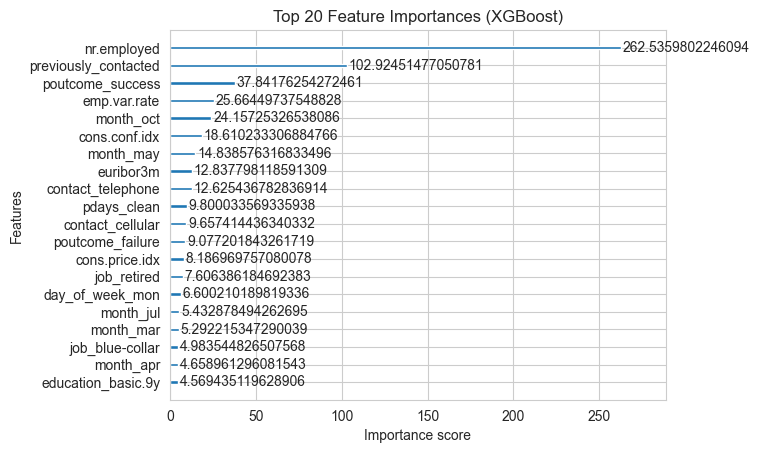

In [79]:
plt.figure(figsize=(10, 12))
plot_importance(
    xgb_baseline,
    max_num_features=20,
    importance_type="gain"
)
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()

In [80]:
base_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "n_estimators": 500,
    "learning_rate": 0.1,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0,
    "reg_lambda": 1,
    "min_child_weight": 1,
    "random_state": 42,
    "early_stopping_rounds": 30
}

In [84]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, average_precision_score
import pandas as pd
import matplotlib.pyplot as plt

def run_xgb_experiment(param_name, values, base_params, X_train, y_train, X_val, y_val):
    results = []
    curves = {}

    for val in values:
        params = base_params.copy()
        params[param_name] = val

        model = XGBClassifier(**params)

        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False
        )

        val_pred = model.predict(X_val)
        val_prob = model.predict_proba(X_val)[:, 1]

        evals = model.evals_result()

        results.append({
            param_name: val,
            "best_iteration": model.best_iteration,
            "accuracy": accuracy_score(y_val, val_pred),
            "f1": f1_score(y_val, val_pred),
            "pr_auc": average_precision_score(y_val, val_prob),
            "final_train_logloss": evals["validation_0"]["logloss"][-1],
            "final_val_logloss": evals["validation_1"]["logloss"][-1]
        })

        curves[val] = {
            "train": evals["validation_0"]["logloss"],
            "val": evals["validation_1"]["logloss"]
        }

    return pd.DataFrame(results), curves

In [85]:
lr_values = [0.01, 0.1, 0.3]

lr_results, lr_curves = run_xgb_experiment(
    param_name="learning_rate",
    values=lr_values,
    base_params=base_params,
    X_train=X_train_enc,
    y_train=y_train,
    X_val=X_val_enc,
    y_val=y_val
)

lr_results

,learning_rate,best_iteration,accuracy,f1,pr_auc,final_train_logloss,final_val_logloss
0,0.01,499,0.901910,0.346983,0.492427,0.266519,0.267127
1,0.10,91,0.902719,0.379773,0.491665,0.257893,0.266426
2,0.30,43,0.899320,0.350731,0.484813,0.249652,0.268731


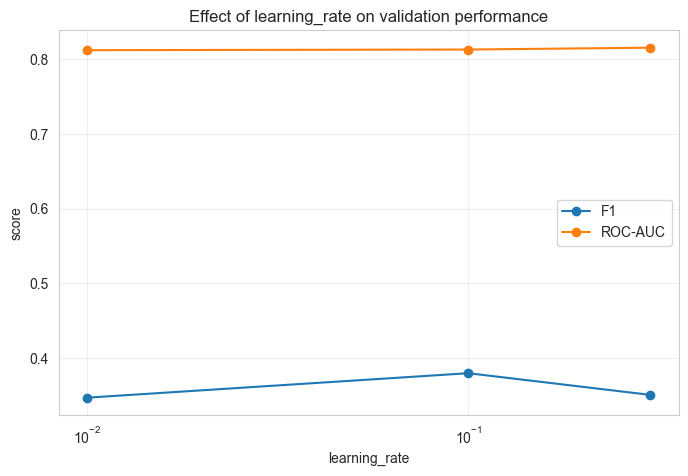

In [83]:
plt.figure(figsize=(8,5))
plt.plot(lr_results["learning_rate"], lr_results["f1"], marker="o", label="F1")
plt.plot(lr_results["learning_rate"], lr_results["roc_auc"], marker="o", label="ROC-AUC")
plt.xscale("log")
plt.xlabel("learning_rate")
plt.ylabel("score")
plt.title("Effect of learning_rate on validation performance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

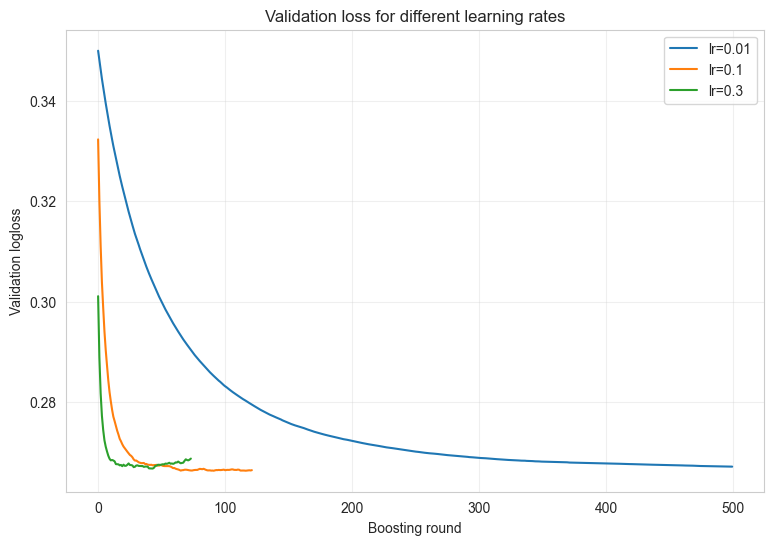

In [78]:
plt.figure(figsize=(9,6))
for val in lr_values:
    plt.plot(lr_curves[val]["val"], label=f"lr={val}")
plt.xlabel("Boosting round")
plt.ylabel("Validation logloss")
plt.title("Validation loss for different learning rates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [86]:
n_estimators_values = [100, 300, 500, 800, 1000]

n_estimators_results, n_estimators_curves = run_xgb_experiment(
    param_name="n_estimators",
    values=n_estimators_values,
    base_params=base_params,
    X_train=X_train_enc,
    y_train=y_train,
    X_val=X_val_enc,
    y_val=y_val
)

n_estimators_results

,n_estimators,best_iteration,accuracy,f1,pr_auc,final_train_logloss,final_val_logloss
0,100,91,0.902719,0.379773,0.491665,0.260166,0.266526
1,300,91,0.902719,0.379773,0.491665,0.257893,0.266426
2,500,91,0.902719,0.379773,0.491665,0.257893,0.266426
3,800,91,0.902719,0.379773,0.491665,0.257893,0.266426
4,1000,91,0.902719,0.379773,0.491665,0.257893,0.266426


In [87]:
max_depth_values = [2, 3, 4, 5, 6, 8]

max_depth_results, max_depth_curves = run_xgb_experiment(
    param_name="max_depth",
    values=max_depth_values,
    base_params=base_params,
    X_train=X_train_enc,
    y_train=y_train,
    X_val=X_val_enc,
    y_val=y_val
)

max_depth_results

,max_depth,best_iteration,accuracy,f1,pr_auc,final_train_logloss,final_val_logloss
0,2,308,0.899644,0.343220,0.486768,0.266791,0.267405
1,3,141,0.900939,0.354430,0.488347,0.263348,0.267060
2,4,91,0.902719,0.379773,0.491665,0.257893,0.266426
3,5,83,0.901748,0.370984,0.497384,0.248226,0.265378
4,6,65,0.900615,0.363071,0.493587,0.238146,0.265281
5,8,41,0.902719,0.393542,0.494901,0.218034,0.266742


In [88]:
subsample_values = [0.6, 0.8, 1.0]

subsample_results, subsample_curves = run_xgb_experiment(
    param_name="subsample",
    values=subsample_values,
    base_params=base_params,
    X_train=X_train_enc,
    y_train=y_train,
    X_val=X_val_enc,
    y_val=y_val
)

subsample_results

,subsample,best_iteration,accuracy,f1,pr_auc,final_train_logloss,final_val_logloss
0,0.6,70,0.902719,0.359957,0.493847,0.260077,0.266483
1,0.8,91,0.902719,0.379773,0.491665,0.257893,0.266426
2,1.0,71,0.900777,0.352693,0.492057,0.262070,0.267449


In [89]:
reg_alpha_values = [0, 0.01, 0.1, 1, 5]

reg_alpha_results, reg_alpha_curves = run_xgb_experiment(
    param_name="reg_alpha",
    values=reg_alpha_values,
    base_params=base_params,
    X_train=X_train_enc,
    y_train=y_train,
    X_val=X_val_enc,
    y_val=y_val
)

reg_alpha_results

,reg_alpha,best_iteration,accuracy,f1,pr_auc,final_train_logloss,final_val_logloss
0,0.00,91,0.902719,0.379773,0.491665,0.257893,0.266426
1,0.01,78,0.901263,0.363257,0.492518,0.259052,0.266174
2,0.10,65,0.901910,0.363445,0.492094,0.260646,0.266426
3,1.00,114,0.901586,0.365344,0.492363,0.255953,0.266783
4,5.00,187,0.903043,0.384378,0.493574,0.256076,0.265560


In [90]:
reg_lambda_values = [0.1, 0.5, 1, 5, 10]

reg_lambda_results, reg_lambda_curves = run_xgb_experiment(
    param_name="reg_lambda",
    values=reg_lambda_values,
    base_params=base_params,
    X_train=X_train_enc,
    y_train=y_train,
    X_val=X_val_enc,
    y_val=y_val
)

reg_lambda_results

,reg_lambda,best_iteration,accuracy,f1,pr_auc,final_train_logloss,final_val_logloss
0,0.1,66,0.901424,0.359621,0.493750,0.259449,0.266229
1,0.5,113,0.902557,0.371608,0.489316,0.254962,0.267209
2,1.0,91,0.902719,0.379773,0.491665,0.257893,0.266426
3,5.0,125,0.901424,0.367601,0.493585,0.257019,0.266101
4,10.0,137,0.902072,0.371755,0.492281,0.257761,0.265945


# Compare

In [91]:
final_mlp = best_mlp
final_xgb = xgb_baseline

In [92]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, average_precision_score
)
import pandas as pd

# ---- MLP test metrics ----
mlp_test_pred = final_mlp.predict(X_test_processed)
mlp_test_prob = final_mlp.predict_proba(X_test_processed)[:, 1]

mlp_results = {
    "Model": "MLP",
    "Accuracy": accuracy_score(y_test, mlp_test_pred),
    "Precision": precision_score(y_test, mlp_test_pred),
    "Recall": recall_score(y_test, mlp_test_pred),
    "F1-score": f1_score(y_test, mlp_test_pred),
    "AUC-PR": average_precision_score(y_test, mlp_test_prob)
}

# ---- XGBoost / GBDT test metrics ----
xgb_test_pred = final_xgb.predict(X_test_enc)
xgb_test_prob = final_xgb.predict_proba(X_test_enc)[:, 1]

xgb_results = {
    "Model": "GBDT (XGBoost)",
    "Accuracy": accuracy_score(y_test, xgb_test_pred),
    "Precision": precision_score(y_test, xgb_test_pred),
    "Recall": recall_score(y_test, xgb_test_pred),
    "F1-score": f1_score(y_test, xgb_test_pred),
    "AUC-PR": average_precision_score(y_test, xgb_test_prob)
}

comparison_df = pd.DataFrame([mlp_results, xgb_results])
comparison_df

,Model,Accuracy,Precision,Recall,F1-score,AUC-PR
0,MLP,0.898204,0.665025,0.193966,0.300334,0.402853
1,GBDT (XGBoost),0.901117,0.669323,0.241379,0.354805,0.481968


In [99]:
import time
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# ----------------------------
# Retrain baseline GBDT
# ----------------------------
gbdt_timed = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=500,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    min_child_weight=1,
    random_state=42,
    early_stopping_rounds=30
)

start_gbdt = time.perf_counter()

gbdt_timed.fit(
    X_train_enc, y_train,
    eval_set=[(X_val_enc, y_val)],
    verbose=False
)

end_gbdt = time.perf_counter()
gbdt_train_time = end_gbdt - start_gbdt

print("GBDT training time (seconds):", round(gbdt_train_time, 4))

GBDT training time (seconds): 0.2877


In [100]:
# ----------------------------
# Retrain best MLP
# ----------------------------
mlp_timed = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # replace with your best params
    activation="relu",
    learning_rate_init=0.1,
    max_iter=600,
    random_state=42
)

start_mlp = time.perf_counter()

mlp_timed.fit(X_train_processed, y_train)

end_mlp = time.perf_counter()
mlp_train_time = end_mlp - start_mlp

print("MLP training time (seconds):", round(mlp_train_time, 4))

MLP training time (seconds): 1.2417
